# Traffic flow forecast 

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns

In [6]:

data_loc = r"~/Desktop/Data Playground/Traffic Flow Forecasting and Analysis"
data_name="traffic_sensor_data.csv"
#df = pd.read_csv(f"{data_loc}/{data_name}") # Linux Option
df = pd.read_csv(f"{data_name}") # Windows Option

## EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218400 entries, 0 to 218399
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          218400 non-null  object 
 1   sensor_id          218400 non-null  object 
 2   location           218400 non-null  object 
 3   direction          218400 non-null  object 
 4   vehicle_count      218400 non-null  int64  
 5   average_speed_kmh  218400 non-null  float64
 6   occupancy_rate     218400 non-null  float64
 7   congestion_level   218400 non-null  object 
 8   car_count          218400 non-null  int64  
 9   motorcycle_count   218400 non-null  int64  
 10  truck_count        218400 non-null  int64  
 11  bus_count          218400 non-null  int64  
 12  day_of_week        218400 non-null  int64  
 13  is_holiday         218400 non-null  int64  
 14  hour               218400 non-null  int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 25

In [46]:
df.head()

,timestamp,sensor_id,location,direction,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
0,2024-01-01 00:00:00,SEN-001,Jl. Sudirman - Bundaran HI,North,14,67.8,0.073,Low,6,5,1,2,0,1,0
1,2024-01-01 00:00:00,SEN-002,Jl. Thamrin - Monas,South-West,23,66.8,0.075,Low,10,8,1,4,0,1,0
2,2024-01-01 00:00:00,SEN-003,Jl. Gatot Subroto - Kuningan,East,22,80.0,0.161,Low,7,9,1,5,0,1,0
3,2024-01-01 00:00:00,SEN-004,Jl. Rasuna Said - Setiabudi,East,8,80.0,0.055,Low,3,2,0,3,0,1,0
4,2024-01-01 00:00:00,SEN-005,Jl. HR Rasuna Said - Casablanca,East,13,80.0,0.097,Low,5,5,0,3,0,1,0


In [47]:
df["sensor_id"].unique()

<StringArray>
['SEN-001', 'SEN-002', 'SEN-003', 'SEN-004', 'SEN-005', 'SEN-006', 'SEN-007',
 'SEN-008', 'SEN-009', 'SEN-010', 'SEN-011', 'SEN-012', 'SEN-013', 'SEN-014',
 'SEN-015', 'SEN-016', 'SEN-017', 'SEN-018', 'SEN-019', 'SEN-020', 'SEN-021',
 'SEN-022', 'SEN-023', 'SEN-024', 'SEN-025', 'SEN-026', 'SEN-027', 'SEN-028',
 'SEN-029', 'SEN-030', 'SEN-031', 'SEN-032', 'SEN-033', 'SEN-034', 'SEN-035',
 'SEN-036', 'SEN-037', 'SEN-038', 'SEN-039', 'SEN-040', 'SEN-041', 'SEN-042',
 'SEN-043', 'SEN-044', 'SEN-045', 'SEN-046', 'SEN-047', 'SEN-048', 'SEN-049',
 'SEN-050']
Length: 50, dtype: str

In [48]:
df[df['sensor_id'] == 'SEN-002']

,timestamp,sensor_id,location,direction,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
1,2024-01-01 00:00:00,SEN-002,Jl. Thamrin - Monas,South-West,23,66.8,0.075,Low,10,8,1,4,0,1,0
51,2024-01-01 00:30:00,SEN-002,Jl. Thamrin - Monas,South,28,80.0,0.183,Low,10,9,2,7,0,1,0
101,2024-01-01 01:00:00,SEN-002,Jl. Thamrin - Monas,South-West,24,80.0,0.154,Low,9,10,2,3,0,1,1
151,2024-01-01 01:30:00,SEN-002,Jl. Thamrin - Monas,South,28,80.0,0.176,Low,11,11,2,4,0,1,1
201,2024-01-01 02:00:00,SEN-002,Jl. Thamrin - Monas,South-West,11,80.0,0.083,Low,5,4,0,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218151,2024-03-31 21:30:00,SEN-002,Jl. Thamrin - Monas,South,23,80.0,0.087,Low,8,8,1,6,6,1,21
218201,2024-03-31 22:00:00,SEN-002,Jl. Thamrin - Monas,North-East,21,80.0,0.110,Low,9,8,1,3,6,1,22
218251,2024-03-31 22:30:00,SEN-002,Jl. Thamrin - Monas,South-West,27,80.0,0.072,Low,13,9,2,3,6,1,22
218301,2024-03-31 23:00:00,SEN-002,Jl. Thamrin - Monas,South-West,8,80.0,0.050,Low,3,2,0,3,6,1,23


In [55]:
df.keys()

Index(['timestamp', 'sensor_id', 'location', 'direction', 'vehicle_count',
       'average_speed_kmh', 'occupancy_rate', 'congestion_level', 'car_count',
       'motorcycle_count', 'truck_count', 'bus_count', 'day_of_week',
       'is_holiday', 'hour'],
      dtype='str')

In [56]:
df['is_holiday'].unique()

array([1, 0])

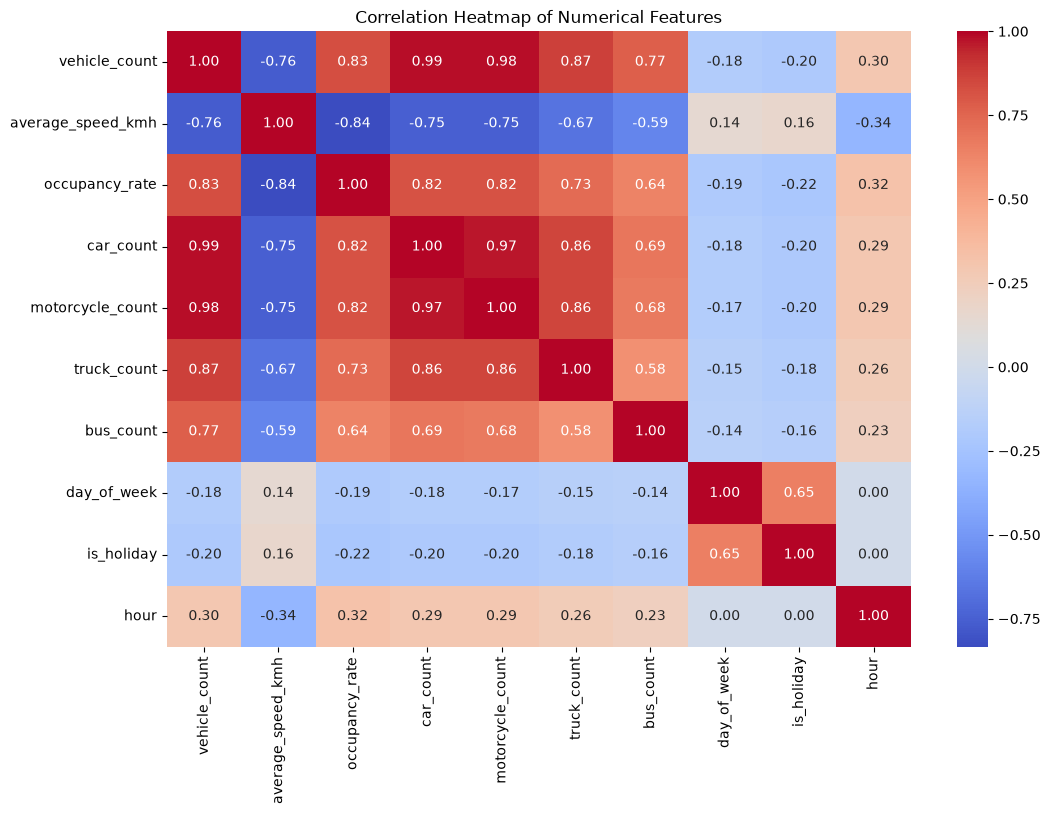

In [ ]:
import seaborn as sns

# Calculate correlation matrix
corr = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Feature Engineering

In [ ]:
def feature_engineering(
    df,
    target_column='vehicle_count',
    one_hot_sensor=True,
    add_lags=True,
    drop_lag_na=True,
    lag_steps=(1, 2),
    rolling_windows=(6, 48),
):
    modern_df = df.copy()

    # Ensure timestamp is datetime and keep stable temporal order by sensor
    modern_df['timestamp'] = pd.to_datetime(modern_df['timestamp'])
    modern_df = modern_df.sort_values(['sensor_id', 'timestamp']).reset_index(drop=True)

    # Calendar features
    modern_df['month'] = modern_df['timestamp'].dt.month
    modern_df['day'] = modern_df['timestamp'].dt.day
    modern_df['hour'] = modern_df['timestamp'].dt.hour
    modern_df['minute'] = modern_df['timestamp'].dt.minute
    modern_df['day_of_week'] = modern_df['timestamp'].dt.dayofweek

    # Cyclical features requested: day, hour and day_of_week
    modern_df['day_sin'] = np.sin(2 * np.pi * modern_df['day'] / 31)
    modern_df['day_cos'] = np.cos(2 * np.pi * modern_df['day'] / 31)
    modern_df['hour_sin'] = np.sin(2 * np.pi * modern_df['hour'] / 24)
    modern_df['hour_cos'] = np.cos(2 * np.pi * modern_df['hour'] / 24)
    modern_df['day_of_week_sin'] = np.sin(2 * np.pi * modern_df['day_of_week'] / 7)
    modern_df['day_of_week_cos'] = np.cos(2 * np.pi * modern_df['day_of_week'] / 7)

    # Extra 30-minute cyclic signal to preserve intra-hour pattern
    modern_df['slot_30m'] = modern_df['hour'] * 2 + (modern_df['minute'] // 30)
    modern_df['slot_30m_sin'] = np.sin(2 * np.pi * modern_df['slot_30m'] / 48)
    modern_df['slot_30m_cos'] = np.cos(2 * np.pi * modern_df['slot_30m'] / 48)

    # Optional monthly cycle
    modern_df['month_sin'] = np.sin(2 * np.pi * modern_df['month'] / 12)
    modern_df['month_cos'] = np.cos(2 * np.pi * modern_df['month'] / 12)

    # Encode congestion level (fallback -1 for unseen labels)
    congestion_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
    modern_df['congestion_level'] = modern_df['congestion_level'].map(congestion_mapping).fillna(-1).astype('int16')

    # Lag features by sensor: lag 1 = 30 minutes, lag 2 = 60 minutes
    if add_lags:
        for step in lag_steps:
            modern_df[f'{target_column}_lag_{step}'] = modern_df.groupby('sensor_id')[target_column].shift(step)

        for w in rolling_windows:
            modern_df[f'{target_column}_roll_mean_{w}'] = modern_df.groupby('sensor_id')[target_column].transform(
                lambda s: s.shift(1).rolling(w).mean()
            )

    # sensor_id encoding for tabular models
    if one_hot_sensor:
        modern_df = pd.get_dummies(modern_df, columns=['sensor_id'], drop_first=True, dtype='int8')
    else:
        modern_df['sensor_id'] = modern_df['sensor_id'].astype('category')

    columns_to_drop = [
        'timestamp', 'location', 'direction',
        'car_count', 'motorcycle_count', 'truck_count', 'bus_count',
        'month', 'day', 'hour', 'minute', 'day_of_week'
    ]
    columns_to_drop = [c for c in columns_to_drop if c in modern_df.columns]
    modern_df.drop(columns=columns_to_drop, inplace=True)

    if add_lags and drop_lag_na:
        lag_cols = [
            c for c in modern_df.columns
            if c.startswith(f'{target_column}_lag_') or c.startswith(f'{target_column}_roll_mean_')
        ]
        modern_df = modern_df.dropna(subset=lag_cols).reset_index(drop=True)

    return modern_df

def classical_feature_engineering(df, time_column='timestamp', target_column='vehicle_count'):
    classical_df = df.copy()
    classical_df[time_column] = pd.to_datetime(classical_df[time_column])
    classical_df.set_index(time_column, inplace=True)

    classical_df = classical_df.rename(columns={target_column: 'y'})
    return classical_df

### Classical Approach

In [45]:
classical_df = classical_feature_engineering(df, time_column='timestamp', target_column='vehicle_count')

In [ ]:
# Daily Closing Price Plot
classical_df["y"].plot()
plt.show()

In [ ]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(classical_df['y'], lags = 100, ax = ax)
plt.show()

In [ ]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(classical_df['y'], lags = 100, ax = ax)
plt.show()

### Modern Approach

In [46]:
freq_df = df.copy()
freq_df['timestamp'] = pd.to_datetime(freq_df['timestamp'])
freq_df = freq_df.sort_values(['sensor_id', 'timestamp']).reset_index(drop=True)

freq_df['delta_min'] = (
    freq_df.groupby('sensor_id')['timestamp']
    .diff()
    .dt.total_seconds()
    .div(60)
 )

freq_summary = (
    freq_df.dropna(subset=['delta_min'])
    .groupby('sensor_id')['delta_min']
    .agg(
        n_obs='count',
        modal_delta_min=lambda s: s.mode().iloc[0],
        pct_30min=lambda s: (s == 30).mean()
    )
    .sort_values('pct_30min', ascending=False)
 )

print('Sensors with >= 95% of 30-minute steps:', (freq_summary['pct_30min'] >= 0.95).sum())
display(freq_summary.head(10))

Sensors with >= 95% of 30-minute steps: 50


,n_obs,modal_delta_min,pct_30min
sensor_id,,,
SEN-001,4367,30.0,1.0
SEN-002,4367,30.0,1.0
SEN-003,4367,30.0,1.0
SEN-004,4367,30.0,1.0
SEN-005,4367,30.0,1.0
SEN-006,4367,30.0,1.0
SEN-007,4367,30.0,1.0
SEN-008,4367,30.0,1.0
SEN-009,4367,30.0,1.0


#### Frequency Check Per Sensor (30-minute hypothesis)
Validamos si el paso temporal modal por sensor es de 30 minutos antes de entrenar.

In [47]:
modern_df = feature_engineering(
    df,
    target_column='vehicle_count',
    one_hot_sensor=True,
    add_lags=True,
    drop_lag_na=True,
    lag_steps=(1, 2)
 )
modern_df.info()
modern_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216000 entries, 0 to 215999
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   sensor_id                   216000 non-null  object 
 1   vehicle_count               216000 non-null  int64  
 2   average_speed_kmh           216000 non-null  float64
 3   occupancy_rate              216000 non-null  float64
 4   congestion_level            216000 non-null  int16  
 5   is_holiday                  216000 non-null  int64  
 6   slot_30m                    216000 non-null  int32  
 7   slot_30m_sin                216000 non-null  float64
 8   slot_30m_cos                216000 non-null  float64
 9   dow_sin                     216000 non-null  float64
 10  dow_cos                     216000 non-null  float64
 11  month_sin                   216000 non-null  float64
 12  month_cos                   216000 non-null  float64
 13  vehicle_count_

,sensor_id,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,is_holiday,slot_30m,slot_30m_sin,slot_30m_cos,dow_sin,dow_cos,month_sin,month_cos,vehicle_count_lag_1,vehicle_count_lag_2,vehicle_count_roll_mean_6,vehicle_count_roll_mean_48
0,SEN-001,5,80.0,0.040,1,0,0,0.000000,1.000000,0.781831,0.62349,0.5,0.866025,31.0,15.0,26.666667,42.812500
1,SEN-001,12,80.0,0.160,1,0,1,0.130526,0.991445,0.781831,0.62349,0.5,0.866025,5.0,31.0,24.333333,42.625000
2,SEN-001,9,80.0,0.077,1,0,2,0.258819,0.965926,0.781831,0.62349,0.5,0.866025,12.0,5.0,22.500000,42.437500
3,SEN-001,14,80.0,0.096,1,0,3,0.382683,0.923880,0.781831,0.62349,0.5,0.866025,9.0,12.0,19.500000,42.187500
4,SEN-001,7,69.1,0.126,1,0,4,0.500000,0.866025,0.781831,0.62349,0.5,0.866025,14.0,9.0,14.333333,41.958333


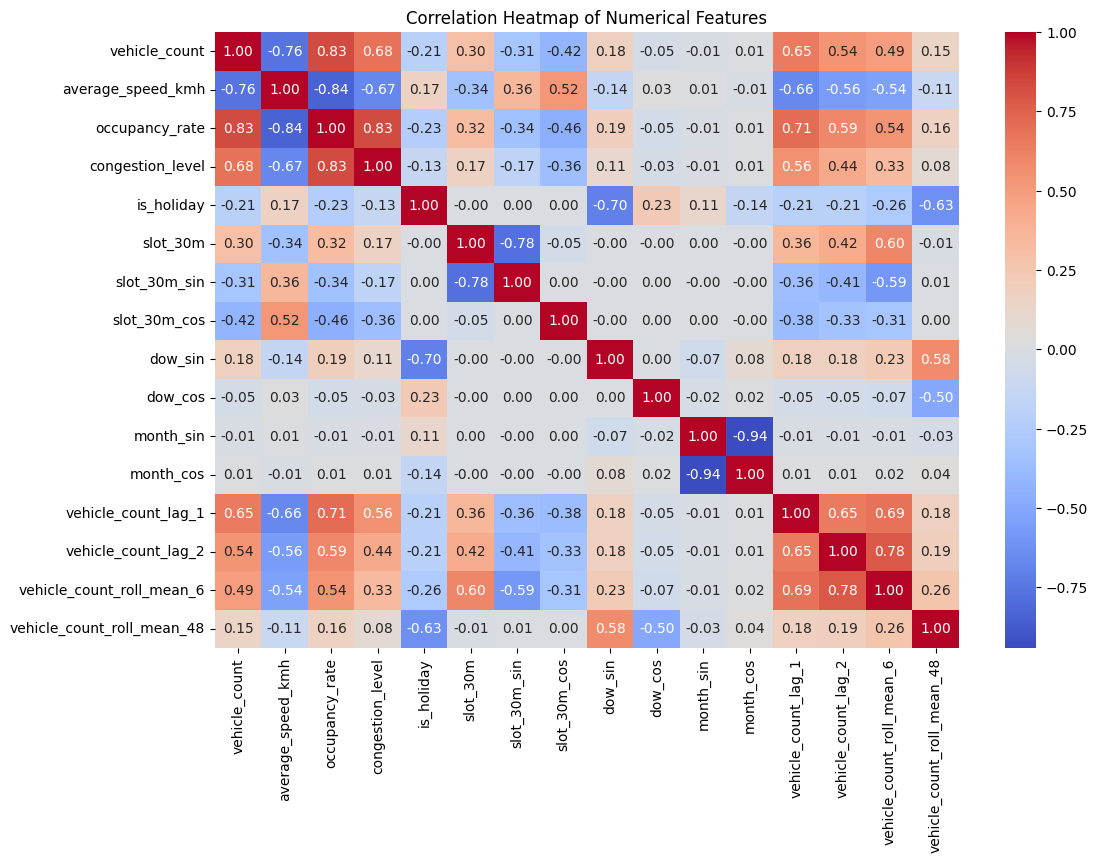

In [48]:
import seaborn as sns

# Calculate correlation matrix
corr = modern_df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [49]:
from sklearn.tree import DecisionTreeRegressor

def select_features(df, target_column, threshold=0.01):
    """
    Selects features based on Decision Tree feature importance.
    """
    # Ensure we only use numerical columns
    numerical_df = df.select_dtypes(include=['number']).dropna()
    
    if target_column not in numerical_df.columns:
        print(f"Target column {target_column} not found in numerical columns.")
        return numerical_df.columns.tolist()

    X = numerical_df.drop(columns=[target_column])
    y = numerical_df[target_column]

    # Initialize and fit Decision Tree
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X, y)

    # Get feature importances
    importances = pd.Series(model.feature_importances_, index=X.columns)
    
    # Select features above threshold
    selected_features = importances[importances > threshold].sort_values(ascending=False).index.tolist()
        
    return selected_features

# Example usage:
selected = select_features(modern_df, 'vehicle_count')
print("Selected Features:", selected)

Selected Features: ['occupancy_rate', 'vehicle_count_roll_mean_6', 'vehicle_count_roll_mean_48', 'average_speed_kmh', 'vehicle_count_lag_2', 'vehicle_count_lag_1', 'slot_30m_cos', 'dow_sin']


# Models 

### LightGBM/Catboost 

### TFT

### Modern Techniques: AutoGluon